In [ ]:
import pandas as pd 
import numpy as np 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("c:\\Users\\a\\Downloads\\india_housing_prices.csv")

In [ ]:
df.head(4)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move


In [ ]:
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

***Data Acquisition, Cleaning, and Exploratory Analysis***

In [ ]:
df.shape

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [8]:
df["Price_per_SqFt"]=df["Price_in_Lakhs"]/df["Size_in_SqFt"]

In [9]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Locality'] = df['Locality'].astype('category')


In [12]:
(df.isnull().sum() / df.shape[0]) * 100

ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64

In [13]:
import pandas as pd

# Step 1: Memory usage before conversion
before_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage before conversion: {before_mem / 1024**2:.2f} MB")

# Step 2: Convert object columns to category
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].apply(lambda x: x.astype('category'))

# Step 3: Memory usage after conversion
after_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage after conversion: {after_mem / 1024**2:.2f} MB")


Memory usage before conversion: 194.04 MB
Memory usage after conversion: 24.41 MB


**Numeric columns**

In [14]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130583,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130719,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.002022,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.048028,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.092447,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.159874,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.991820,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [15]:
df.skew(numeric_only=True)

ID                  0.000000
BHK                 0.000543
Size_in_SqFt        0.000796
Price_in_Lakhs      0.008206
Price_per_SqFt      2.320225
Year_Built         -0.000167
Floor_No            0.005311
Total_Floors       -0.000666
Age_of_Property     0.000167
Nearby_Schools     -0.001258
Nearby_Hospitals    0.001099
dtype: float64

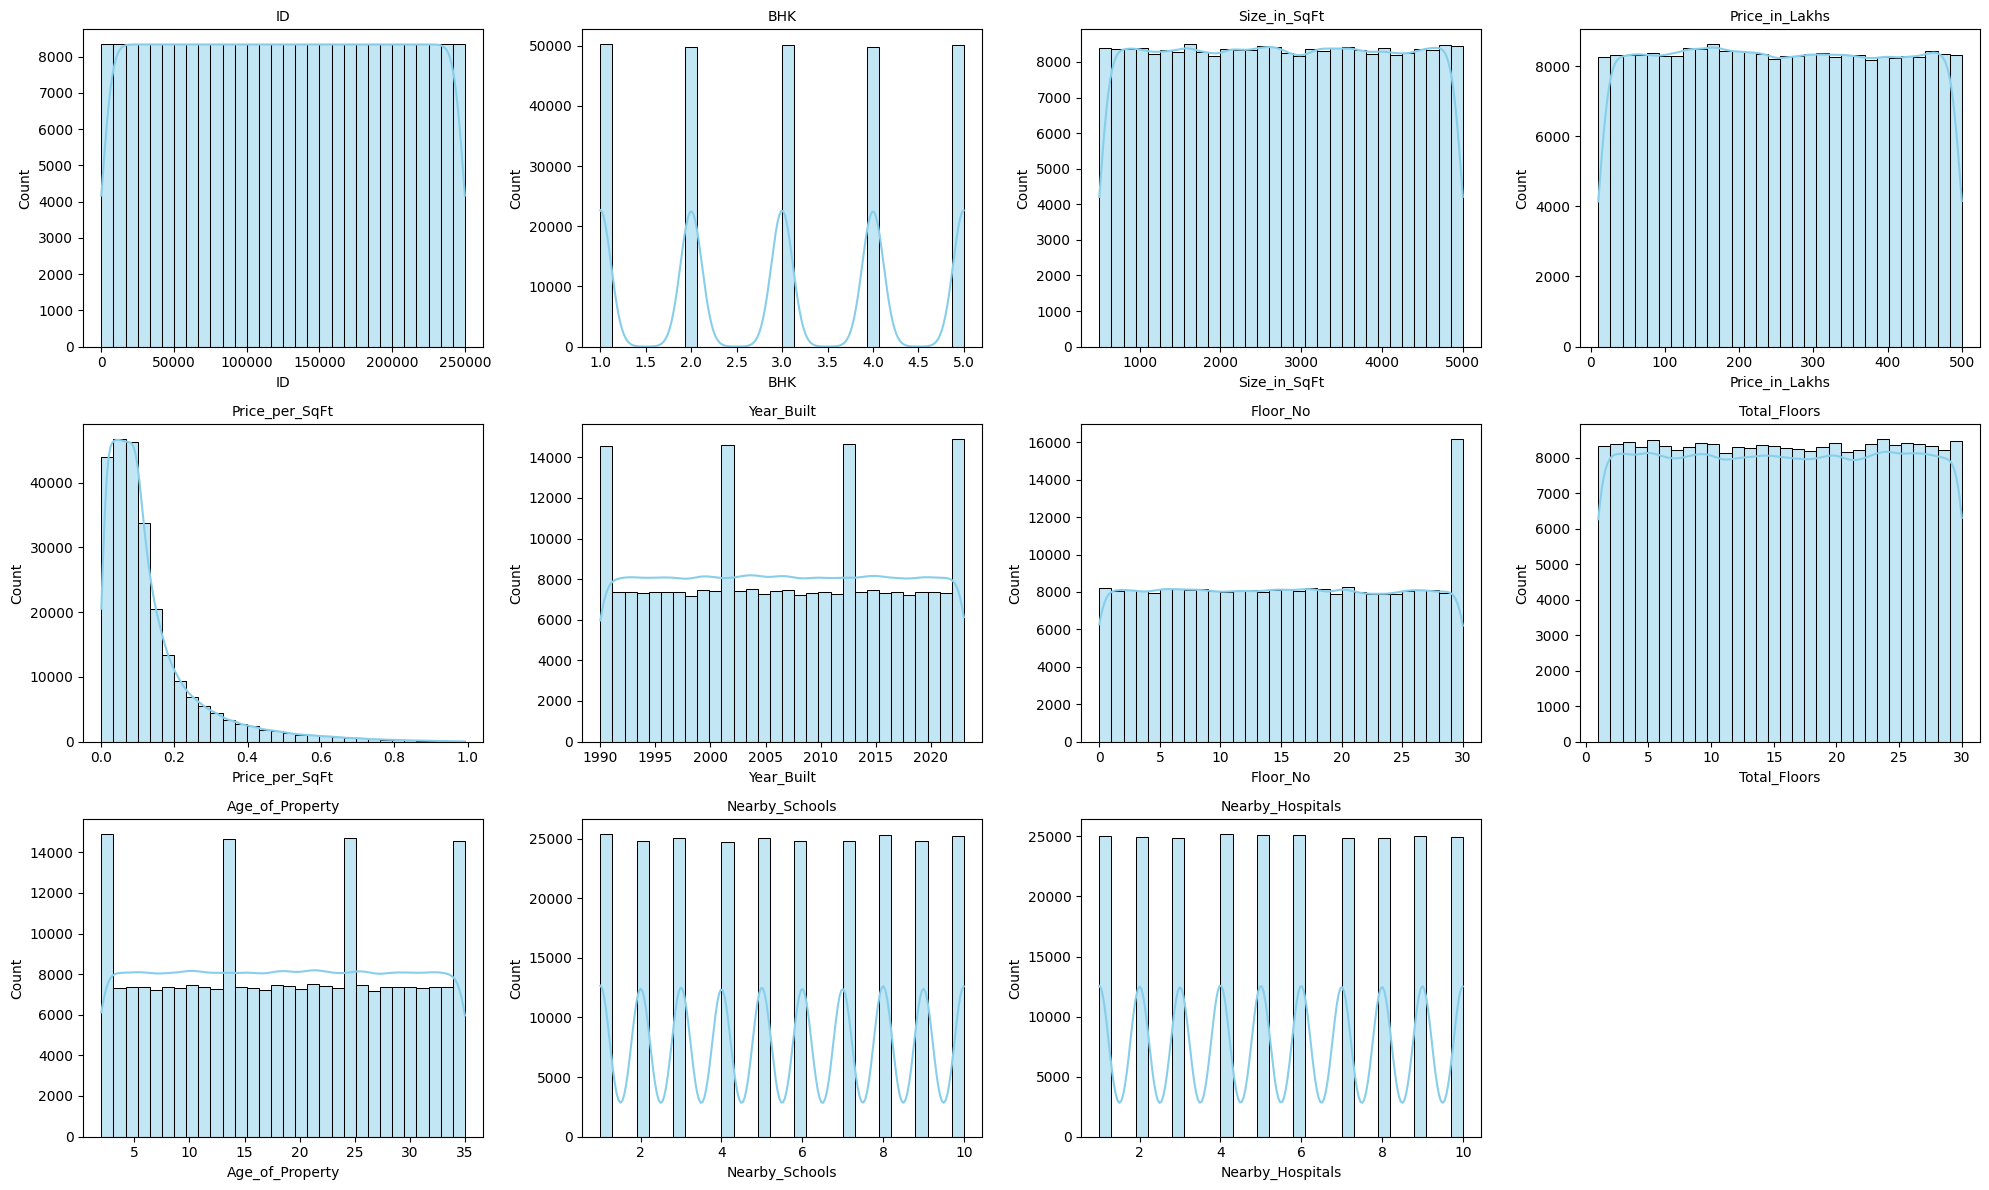

<Figure size 640x480 with 0 Axes>

In [16]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot each numeric column
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f'{col}', fontsize=10)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.savefig("numeric_columns_distribution.png",)  # saves as PNG
plt.show()

#price per SQRft
#


**Categorical colimns**

In [17]:
df.describe(include=["object","category"])

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Odisha,Coimbatore,Locality_296,Villa,Unfurnished,High,No,Yes,Pool,West,Broker,Under_Construction
freq,12681,6461,567,83744,83408,83705,125456,125233,10218,62757,83479,125035


Outlier detection with IQR: For at least two numeric columns, compute Q1 (df[col].quantile(0.25)), Q3 (df[col].quantile(0.75)), IQR = Q3 − Q1, lower bound = Q1 − 1.5 × IQR, and upper bound = Q3 + 1.5 × IQR. Count the number of rows that fall outside these bounds. Do not drop the outliers — instead, document them and state in the README whether you will cap them, retain them, or handle them differently in Part 2, and why.

In [18]:

import pandas as pd

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    outlier_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    }

# Convert to DataFrame for readability
report_df = pd.DataFrame(outlier_report).T
print(report_df)


                            Q1             Q3            IQR   Lower Bound  \
ID                62500.750000  187500.250000  124999.500000 -124998.50000   
BHK                   2.000000       4.000000       2.000000      -1.00000   
Size_in_SqFt       1623.000000    3874.000000    2251.000000   -1753.50000   
Price_in_Lakhs      132.550000     376.880000     244.330000    -233.94500   
Price_per_SqFt        0.048028       0.159874       0.111845      -0.11974   
Year_Built         1998.000000    2015.000000      17.000000    1972.50000   
Floor_No              7.000000      23.000000      16.000000     -17.00000   
Total_Floors          8.000000      23.000000      15.000000     -14.50000   
Age_of_Property      10.000000      27.000000      17.000000     -15.50000   
Nearby_Schools        3.000000       8.000000       5.000000      -4.50000   
Nearby_Hospitals      3.000000       8.000000       5.000000      -4.50000   

                    Upper Bound  Outlier Count  
ID            

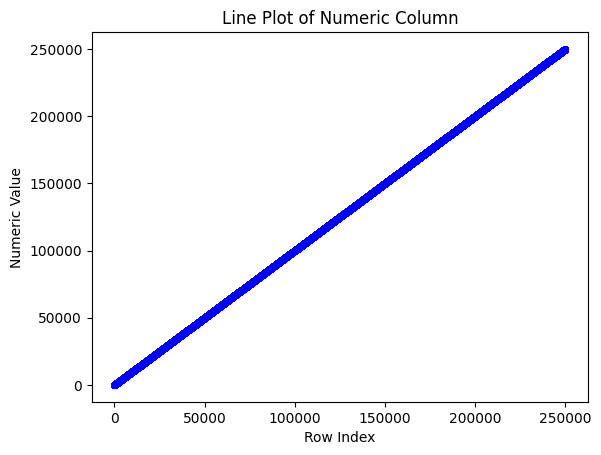

In [19]:
plt.plot(df[numeric_cols[0]], color='blue', marker='o', linestyle='-', markersize=4)

# Add labels and title
plt.title("Line Plot of Numeric Column")
plt.xlabel("Row Index")
plt.ylabel("Numeric Value")

plt.show()

Visualizations (all five types required):

A line plot of one numeric variable sorted by row index or time column (use plt.plot()). Add a title, x-label, and y-label.
A bar chart comparing the mean of one numeric column across categories of one categorical column (use plt.bar() or df.groupby().mean().plot.bar()). Add a title and axis labels.
A histogram of the most skewed numeric column identified in Task 5 (use sns.histplot() with bins=20). Add a title and describe the shape of the distribution in the README.
A scatter plot between two numeric columns that you expect to be correlated (use sns.scatterplot()). Add a title and interpret the direction and approximate strength of the relationship in the README.
A box plot of a numeric column split by a categorical column (use sns.boxplot()). Add a title and describe any visible differences in median and spread across categories.

In [20]:
# import matplotlib.pyplot as plt

# # Select first 10 numeric and first 12 categorical columns
# numeric_cols = df.select_dtypes(include=['int64','float64']).columns[:10]
# categorical_cols = df.select_dtypes(include=['object','category']).columns[:12]

# # Loop through each numeric and categorical column
# for num_col in numeric_cols:
#     for cat_col in categorical_cols:
#         mean_values = df.groupby(cat_col)[num_col].mean().sort_values(ascending=False).head(30)
        
#         # Plot bar chart with eye-catching colors and bigger size
#         plt.figure(figsize=(8,5))
#         mean_values.plot.bar(color=['#FF6F61','#6B5B95','#88B04B'])  # coral, purple, green
        
#         plt.title(f"Top 3 Average {num_col} by {cat_col}", fontsize=14, fontweight='bold')
#         plt.xlabel(cat_col, fontsize=12)
#         plt.ylabel(f"Mean {num_col}", fontsize=12)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.savefig("chart comparing the mean of one numeric column across categories",)
#         plt.show()


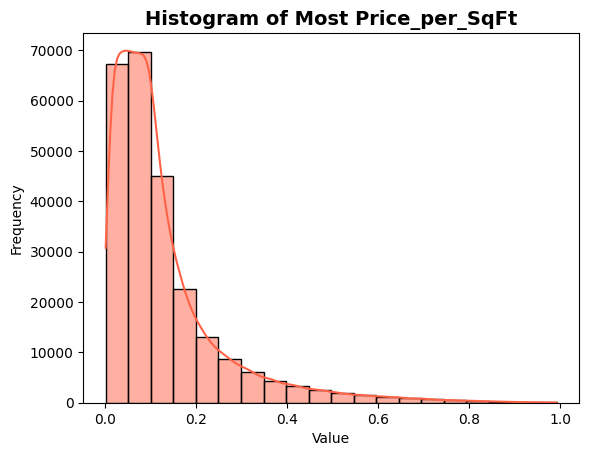

In [21]:
sns.histplot(df['Price_per_SqFt'], bins=20, kde=True, color="tomato")

plt.title("Histogram of Most Price_per_SqFt", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

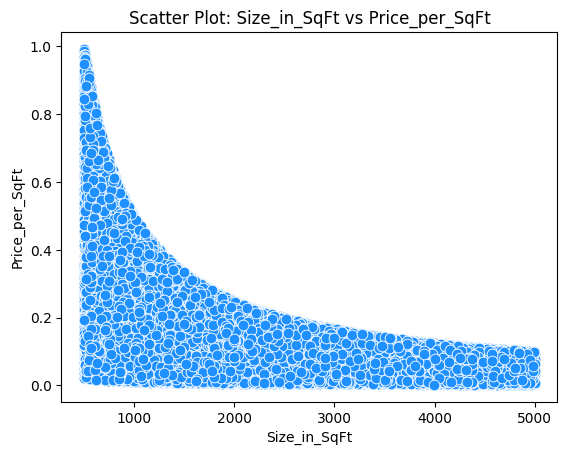

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: numeric columns = 'income' and 'spending'
sns.scatterplot(x=df['Size_in_SqFt'], y=df['Price_per_SqFt'], color="dodgerblue", s=60)

plt.title("Scatter Plot: Size_in_SqFt vs Price_per_SqFt")
plt.xlabel("Size_in_SqFt")
plt.ylabel("Price_per_SqFt")
plt.show()


C:\Users\a\AppData\Local\Temp\ipykernel_27120\151892576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['State'], y=df['City'], palette="Set2",)


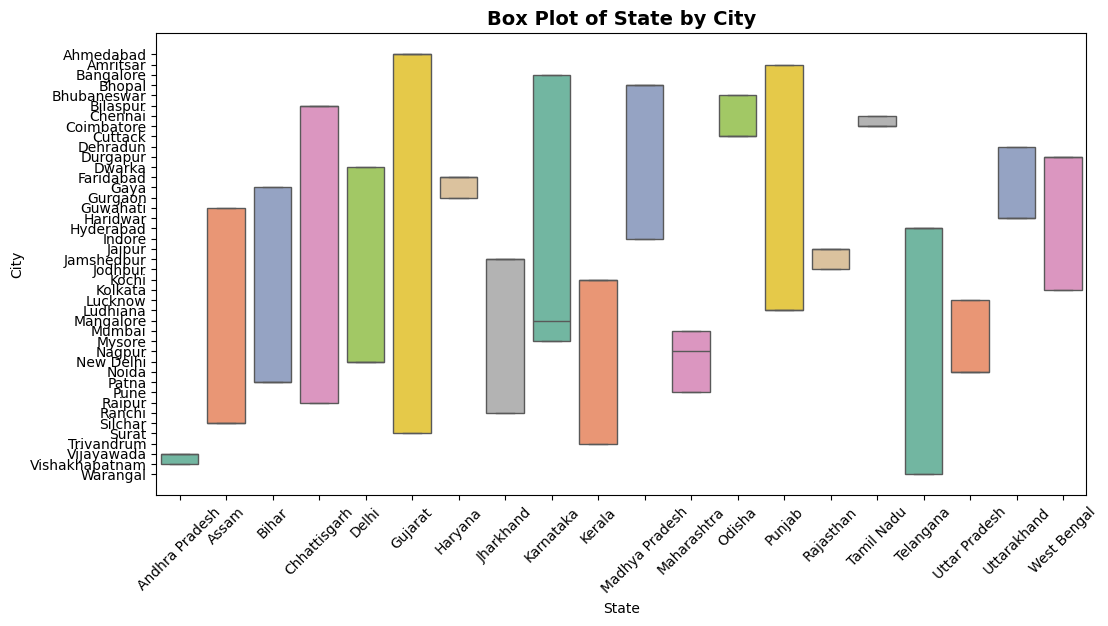

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Example: numeric column = 'sales', categorical column = 'region'
sns.boxplot(x=df['State'], y=df['City'], palette="Set2",)

plt.title("Box Plot of State by City", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("City")
plt.xticks(rotation=45)
plt.show()


(1) Correlation heat map: Compute the correlation matrix of all numeric columns using df.corr(). Visualize it with a heat map (use sns.heatmap() with annot=True). Identify the pair of variables with the highest absolute correlation. In the README, explain whether this correlation might indicate a causal relationship or whether a third variable could explain it, and name at least one plausible alternative explanation.

In [24]:
df.corr(numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,-0.001718,-0.002293,-0.001636,-0.001328,0.002734,-0.000214,0.003382,-0.002734,-0.001203,0.001429
BHK,-0.001718,1.000000,-0.001033,-0.000980,0.001138,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.002293,-0.001033,1.000000,-0.002529,-0.614610,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price_in_Lakhs,-0.001636,-0.000980,-0.002529,1.000000,0.555781,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,-0.001328,0.001138,-0.614610,0.555781,1.000000,-0.001330,-0.001904,0.004161,0.001330,-0.000058,-0.000122
Year_Built,0.002734,0.000917,0.004135,0.002714,-0.001330,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,-0.000214,0.001263,-0.002775,-0.001719,-0.001904,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,0.003382,-0.002862,-0.003451,0.001283,0.004161,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.002734,-0.000917,-0.004135,-0.002714,0.001330,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.001203,-0.000762,0.001966,0.000155,-0.000058,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246


<Axes: >

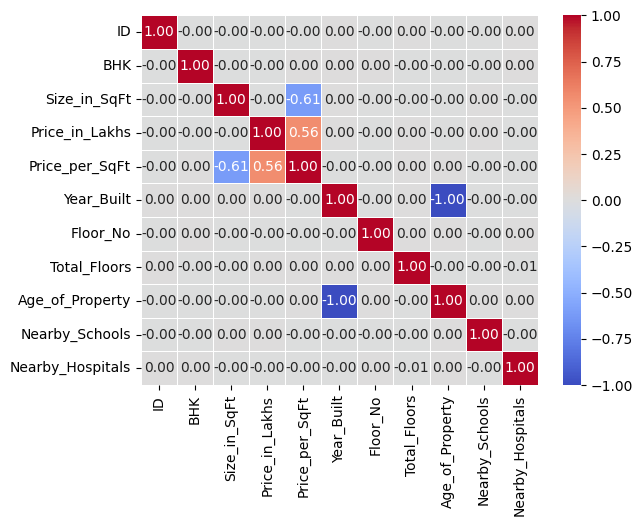

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

"""I used a correlation heatmap to identify relationship 
between numerical fetures.
I found that price_in_lakhs and Price_per_SqFT has a moderate positve
correlation(0.56),while Size_in_SqFt and Price_per_SqFt showed a moderate
negative correlation(-0.61). Year_built and Age_of_property had a perfect negative correlation (-1.0) which is expected because older ,properties have earlier contrucation years.
"""


9.a. Imputation strategy comparison. For the two numeric columns with the highest absolute skewness identified in Task 5, compute both the column mean (df[col].mean()) and the column median (df[col].median()) before any imputation is applied to those columns. Print both values side by side for each column. In the README, state which statistic you chose for imputation and justify the choice based on the skewness direction: for a positively skewed column the mean is pulled upward by extreme high values, making the median a more representative central tendency; for a negatively skewed column the mean is pulled downward by extreme low values, again making the median more representative. Apply your chosen strategy using fillna() to any remaining nulls in those two columns and confirm with isnull().sum() that no nulls remain.

In [26]:
df.head(2)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.103325,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.082707,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


In [27]:


# Step 1: Identify skewness for numeric columns
from scipy.stats import skew
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Step 2: Pick top 2 columns with highest absolute skewness
top2_cols = skew_values.abs().sort_values(ascending=False).head(2).index
print("Top 2 skewed columns:", top2_cols.tolist())

# Step 3: Compute mean and median for each column (before imputation)
for col in top2_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_values[col]:.2f}")

# Step 4: Choose imputation strategy based on skewness direction
# Positively skewed → median; Negatively skewed → median (since mean is pulled away)
for col in top2_cols:
    chosen_val = df[col].median()
    df[col] = df[col].fillna(chosen_val)

# Step 5: Confirm no nulls remain
print("\nNull counts after imputation:\n", df[top2_cols].isnull().sum())


Top 2 skewed columns: ['Price_per_SqFt', 'Price_in_Lakhs']
Price_per_SqFt: mean=0.13, median=0.09, skew=2.32
Price_in_Lakhs: mean=254.59, median=253.87, skew=0.01

Null counts after imputation:
 Price_per_SqFt    0
Price_in_Lakhs    0
dtype: int64


In [28]:
df.corr(method='spearman',	numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,-0.001718,-0.002291,-0.001635,-0.000086,0.002736,-0.000210,0.003384,-0.002736,-0.001205,0.001431
BHK,-0.001718,1.000000,-0.001031,-0.000988,-0.000395,0.000917,0.001255,-0.002862,-0.000917,-0.000763,0.001159
Size_in_SqFt,-0.002291,-0.001031,1.000000,-0.002529,-0.598552,0.004135,-0.002773,-0.003450,-0.004135,0.001963,-0.001695
Price_in_Lakhs,-0.001635,-0.000988,-0.002529,1.000000,0.751537,0.002723,-0.001732,0.001290,-0.002723,0.000149,-0.002771
Price_per_SqFt,-0.000086,-0.000395,-0.598552,0.751537,1.000000,-0.000639,-0.000442,0.003888,0.000639,-0.002270,-0.001725
Year_Built,0.002736,0.000917,0.004135,0.002723,-0.000639,1.000000,-0.000689,0.003455,-1.000000,-0.000595,-0.002719
Floor_No,-0.000210,0.001255,-0.002773,-0.001732,-0.000442,-0.000689,1.000000,0.001175,0.000689,-0.000639,0.001437
Total_Floors,0.003384,-0.002862,-0.003450,0.001290,0.003888,0.003455,0.001175,1.000000,-0.003455,-0.003088,-0.005873
Age_of_Property,-0.002736,-0.000917,-0.004135,-0.002723,0.000639,-1.000000,0.000689,-0.003455,1.000000,0.000595,0.002719
Nearby_Schools,-0.001205,-0.000763,0.001963,0.000149,-0.002270,-0.000595,-0.000639,-0.003088,0.000595,1.000000,-0.002244


In [29]:
import pandas as pd

# Step 1: Pearson correlation (linear relationships)
pearson_corr = df.corr(method='pearson',	numeric_only=True)

# Step 2: Spearman correlation (rank-based monotonic relationships)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Step 3: Absolute difference matrix
diff_matrix = (spearman_corr - pearson_corr).abs()

# Step 4: Extract top 3 pairs with largest differences
pairs = []
cols = df.select_dtypes(include=['int64','float64']).columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], diff_matrix.loc[cols[i], cols[j]]))

top3 = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

# Step 5: Print results
print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

print("\nTop 3 pairs with largest |Spearman - Pearson| difference:")
for c1, c2, diff in top3:
    print(f"{c1} vs {c2}: |Spearman-Pearson|={diff:.3f}, "
          f"Pearson={pearson_corr.loc[c1,c2]:.3f}, Spearman={spearman_corr.loc[c1,c2]:.3f}")


Pearson Correlation Matrix:
                         ID       BHK  Size_in_SqFt  Price_in_Lakhs  \
ID                1.000000 -0.001718     -0.002293       -0.001636   
BHK              -0.001718  1.000000     -0.001033       -0.000980   
Size_in_SqFt     -0.002293 -0.001033      1.000000       -0.002529   
Price_in_Lakhs   -0.001636 -0.000980     -0.002529        1.000000   
Price_per_SqFt   -0.001328  0.001138     -0.614610        0.555781   
Year_Built        0.002734  0.000917      0.004135        0.002714   
Floor_No         -0.000214  0.001263     -0.002775       -0.001719   
Total_Floors      0.003382 -0.002862     -0.003451        0.001283   
Age_of_Property  -0.002734 -0.000917     -0.004135       -0.002714   
Nearby_Schools   -0.001203 -0.000762      0.001966        0.000155   
Nearby_Hospitals  0.001429  0.001162     -0.001695       -0.002769   

                  Price_per_SqFt  Year_Built  Floor_No  Total_Floors  \
ID                     -0.001328    0.002734 -0.000214    

In [30]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','category']).columns

In [31]:
numeric_cols 

Index(['ID', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
       'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals'],
      dtype='object')

In [32]:
categorical_cols

Index(['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security',
       'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'],
      dtype='object')

In [33]:
df.groupby(df["State"])["Price_in_Lakhs"].agg(['mean', 'std', 'count'])

C:\Users\a\AppData\Local\Temp\ipykernel_27120\58464695.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df["State"])["Price_in_Lakhs"].agg(['mean', 'std', 'count'])


,mean,std,count
State,,,
Andhra Pradesh,255.197870,141.727467,12462
Assam,252.779235,141.957324,12496
Bihar,254.919040,141.271510,12369
Chhattisgarh,252.676337,142.132552,12456
Delhi,252.529900,141.009557,12552
Gujarat,255.790061,141.920164,12578
Haryana,254.445784,140.881936,12314
Jharkhand,253.610145,142.227911,12480
Karnataka,257.408465,141.417520,12424


In [34]:
df.to_csv("cleaned_housing_data.csv", index=False)